# Identifiants de comtés : audit préalable

Audit exécuté le 7 octobre 2026. Correspondances candidates entre les noms historiques de l’entraînement 2000–2015 et une référence Census figée. Aucune cible réservée 2024–2025 ni nouveau score ne sont consultés. Développement assisté par IA.

In [1]:
import json
from pathlib import Path

import pandas as pd

root = Path.cwd()
evidence = json.loads((root / "reports/county-identity-audit.json").read_text())
crosswalk = pd.read_csv(root / "reports/county-identity-crosswalk.csv", dtype=str)
summary = pd.read_csv(root / "reports/county-identity-summary.csv")
assert evidence["target_access_ready"] is False
assert evidence["new_targets_retrieved"] is False
assert evidence["new_scores_available"] is False
{
    key: evidence[key]
    for key in [
        "training_years",
        "training_rows",
        "training_counties",
        "matched_counties",
        "unmatched_counties",
        "ambiguous_counties",
    ]
}

{'training_years': [2000, 2015],
 'training_rows': 8133,
 'training_counties': 528,
 'matched_counties': 528,
 'unmatched_counties': 0,
 'ambiguous_counties': 0}

## Répartition historique

Les effectifs décrivent le sous-ensemble historique disponible après les jointures scientifiques existantes. Ils ne prouvent pas la couverture future de tous les comtés.

,state,training_counties,matched_counties
0,IA,96,96
1,IL,98,98
2,IN,88,88
3,MI,38,38
4,MN,17,17
5,MO,76,76
6,OH,74,74
7,WI,41,41


<Axes: title={'center': 'Comtés historiques et correspondances candidates'}, xlabel='État', ylabel='Nombre de comtés'>

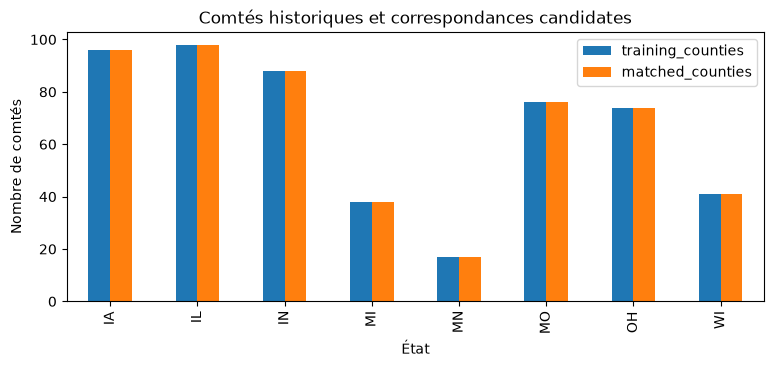

In [2]:
display(summary)
assert len(crosswalk) == int(summary.training_counties.sum())
assert crosswalk.loc[crosswalk.status == "reference_match", "fips"].str.fullmatch(r"[0-9]{5}").all()
assert crosswalk.COUNTY_ID.is_unique
summary.set_index("state")[["training_counties", "matched_counties"]].plot.bar(
    figsize=(9, 3.5),
    title="Comtés historiques et correspondances candidates",
    ylabel="Nombre de comtés",
    xlabel="État",
)

## Codes préservés et limites

La normalisation supprime la ponctuation et les espaces, puis compare dans le même État ; le suffixe County est retiré et city est conservé. Toute collision reste explicite. Un nom/code Census ne suffit pas à établir une identité NASS ni la continuité des frontières. La couverture USDA reste inconnue avant une consultation authentifiée de comptes ; l’équivalence des prédicteurs reste ouverte.

In [3]:
display(
    crosswalk[
        ["COUNTY_ID", "census_county_name", "state_ansi", "county_ansi", "fips", "status"]
    ].head(8)
)
print("SHA-256 de la référence :", evidence["reference_sha256"])
print(
    "Prochaine étape : vérifier les identifiants NASS, les frontières et les prédicteurs avant l’accès aux cibles."
)

,COUNTY_ID,census_county_name,state_ansi,county_ansi,fips,status
0,IA_ADAIR,Adair County,19,001,19001,reference_match
1,IA_ADAMS,Adams County,19,003,19003,reference_match
2,IA_ALLAMAKEE,Allamakee County,19,005,19005,reference_match
3,IA_APPANOOSE,Appanoose County,19,007,19007,reference_match
4,IA_AUDUBON,Audubon County,19,009,19009,reference_match
5,IA_BENTON,Benton County,19,011,19011,reference_match
6,IA_BLACK_HAWK,Black Hawk County,19,013,19013,reference_match
7,IA_BOONE,Boone County,19,015,19015,reference_match


SHA-256 de la référence : 9f6e5f6eb6ac2f5e9a36d5fd01dec77991bddc75118f748a069441a4782970d6
Prochaine étape : vérifier les identifiants NASS, les frontières et les prédicteurs avant l’accès aux cibles.


Sources : [U.S. Census Bureau, codes de comtés](https://www2.census.gov/geo/docs/reference/codes2020/national_county2020.txt), téléchargés le 7 octobre 2026 ; historique [Paudel, de Wit et Boogaard, Zenodo 7751191](https://doi.org/10.5281/zenodo.7751191), CC BY 4.0. Code MIT. Les anciens résultats restent historiques ; aucun nouvel entraînement n’est effectué.